# Optimización combinatoria y TSP: método exacto y búsqueda local (2-opt)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UdeA-IoT/ESP-ACO/blob/main/ACO/metaheuristic-ACO/parte1/notebooks/optimizacion-combinatoria-tsp.ipynb)

**Proyecto:** ESP-ACO (UdeA) — notas complementarias del capítulo 2 de
Dorigo & Stützle, *Ant Colony Optimization* (MIT Press, 2004).

Este notebook complementa el documento de estudio
`optimizacion-combinatoria-2opt.md` con una implementación ejecutable en
Python. Cubre, en orden:

1. Definición formal del problema de optimización combinatoria.
2. El mini-ejemplo de 4 ciudades resuelto por **método exacto**
   (enumeración completa), con grafos, DataFrames y gráficas.
3. El mismo tipo de análisis para **búsqueda local (2-opt)** sobre un
   ejemplo de 6 ciudades, mostrando la evolución paso a paso.

**Librerías usadas:** `pandas`, `numpy`, `itertools`, `networkx`,
`matplotlib`.

In [1]:
import itertools, math
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})


## 1. Definición formal del problema de optimización combinatoria

Una instancia de un problema de optimización combinatoria es una tripleta
$(S, f, \Omega)$, donde:

- $S$ es el conjunto de **soluciones candidatas** (todas las combinaciones
  posibles, sin filtrar).
- $f$ es la **función objetivo**, que asigna un valor $f(s)$ a cada
  solución candidata $s \in S$.
- $\Omega$ es el conjunto de **restricciones** que una solución debe
  cumplir.

Las soluciones de $S$ que cumplen $\Omega$ forman el subconjunto
$\tilde{S} \subseteq S$ de **soluciones factibles**. El objetivo es hallar
una solución globalmente óptima $s^{*}$: la de menor costo en $\tilde{S}$
(minimización) o mayor valor (maximización).

### Traslado al TSP

- $S$ = todas las permutaciones posibles del orden de visita de las $n$
  ciudades (todos los circuitos hamiltonianos posibles sobre el grafo
  completo $G=(N,A)$).
- $\Omega$ = cada ciudad se visita exactamente una vez y se regresa al
  origen. En el TSP, **toda permutación ya cumple $\Omega$ por
  construcción**, así que $\tilde{S} = S$: no hay soluciones candidatas
  infactibles que descartar.
- $f$ = la longitud total del recorrido:

$$
f(\pi) = \sum_{i=1}^{n-1} d_{\pi(i)\pi(i+1)} + d_{\pi(n)\pi(1)}
$$

- $S^{*}$ = el subconjunto (aquí, un único elemento) de $S$ con el menor
  valor de $f$.

En las secciones 2 y 3 estos cinco elementos — $S$, $\Omega$, $f$,
$\tilde{S}$ y $S^{*}$ — se construyen explícitamente en código y se hacen
visibles como filas y columnas de un `DataFrame`, para que la conexión
entre la teoría y la implementación quede clara.

## 2. Planteamiento del mini-ejemplo: TSP de 4 ciudades

Cuatro ciudades ubicadas en las esquinas de un cuadrado de lado 10 km.

In [2]:
coords4 = {"A": (0, 0), "B": (0, 10), "C": (10, 10), "D": (10, 0)}
cities4 = list(coords4.keys())

def dist(p, q, coords):
    return math.dist(coords[p], coords[q])

# Matriz de distancias como DataFrame
dist_matrix4 = pd.DataFrame(
    {c1: {c2: round(dist(c1, c2, coords4), 2) if c1 != c2 else 0.0 for c2 in cities4} for c1 in cities4}
)
dist_matrix4


,A,B,C,D
A,0.00,10.00,14.14,10.00
B,10.00,0.00,10.00,14.14
C,14.14,10.00,0.00,10.00
D,10.00,14.14,10.00,0.00


Grafo completo asociado $G=(N,A)$: cada ciudad es un nodo, cada par de
ciudades está conectado por un arco con peso $d_{ij}$.

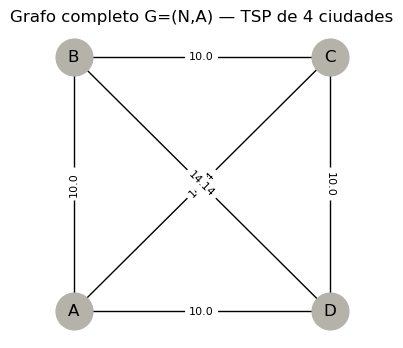

In [3]:
G4 = nx.Graph()
G4.add_nodes_from(cities4)
for c1, c2 in itertools.combinations(cities4, 2):
    G4.add_edge(c1, c2, weight=round(dist(c1, c2, coords4), 2))

fig, ax = plt.subplots(figsize=(4, 4))
nx.draw(G4, pos=coords4, with_labels=True, node_color="#B4B2A9", node_size=700, ax=ax)
edge_labels = nx.get_edge_attributes(G4, "weight")
nx.draw_networkx_edge_labels(G4, pos=coords4, edge_labels=edge_labels, ax=ax, font_size=8)
ax.set_title("Grafo completo G=(N,A) — TSP de 4 ciudades")
plt.show()


## 3. Método exacto: enumeración completa de $S$

Se generan **todas** las permutaciones posibles (fijando la ciudad de
inicio en A, y descartando el reverso de cada tour, ya que representa el
mismo circuito físico). Esto construye $S$ explícitamente. Como se
argumentó en la sección 1, aquí $\tilde{S} = S$: no hay filtrado por
restricciones.

In [4]:
def tour_cost(order, coords):
    return sum(dist(order[i], order[(i + 1) % len(order)], coords) for i in range(len(order)))

start = cities4[0]
others = cities4[1:]
seen = set()
rows = []
for perm in itertools.permutations(others):
    tour = (start,) + perm
    # un tour y su reverso son el mismo circuito -> se cuentan una sola vez
    canon = min(tour, tuple([tour[0]] + list(reversed(tour[1:]))))
    if canon in seen:
        continue
    seen.add(canon)
    cost = tour_cost(tour, coords4)
    rows.append({"tour": " → ".join(tour) + f" → {tour[0]}", "orden": tour, "costo": round(cost, 2)})

df_tours = pd.DataFrame(rows).sort_values("costo").reset_index(drop=True)
df_tours["es_optimo"] = df_tours["costo"] == df_tours["costo"].min()
df_tours[["tour", "costo", "es_optimo"]]


,tour,costo,es_optimo
0,A → B → C → D → A,40.00,True
1,A → B → D → C → A,48.28,False
2,A → C → B → D → A,48.28,False


Esta tabla **es** $S$ (columna `tour`), con $f(\pi)$ evaluada para cada
elemento (columna `costo`), y $S^{*}$ marcado en la columna `es_optimo`.
Con $n=4$ ciudades, $|S| = (n-1)!/2 = 3$.

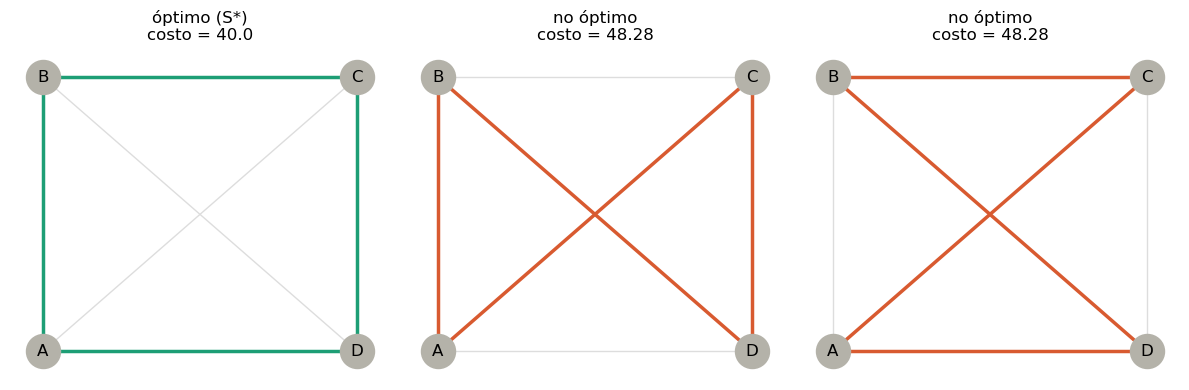

In [5]:
# Visualizacion: un tour por subplot, resaltado sobre el grafo
fig, axes = plt.subplots(1, len(df_tours), figsize=(4 * len(df_tours), 4))
for ax, (_, row) in zip(axes, df_tours.iterrows()):
    order = row["orden"]
    color = "#1D9E75" if row["es_optimo"] else "#D85A30"
    nx.draw(G4, pos=coords4, with_labels=True, node_color="#B4B2A9", node_size=600,
            ax=ax, edge_color="#DDDDDD")
    path_edges = [(order[i], order[(i + 1) % len(order)]) for i in range(len(order))]
    nx.draw_networkx_edges(G4, pos=coords4, edgelist=path_edges, edge_color=color, width=2.5, ax=ax)
    etiqueta = "óptimo (S*)" if row["es_optimo"] else "no óptimo"
    ax.set_title(f"{etiqueta}\ncosto = {row['costo']}")
fig.tight_layout()
plt.show()


### Gráficas descriptivas

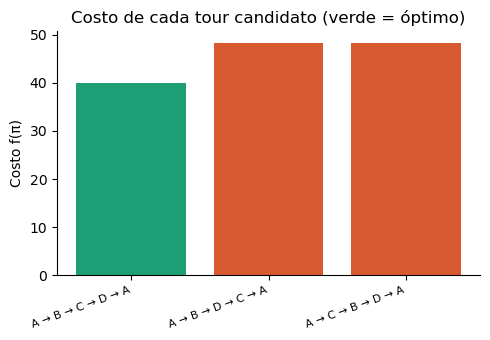

In [6]:
fig, ax = plt.subplots(figsize=(5, 3.5))
colors = ["#1D9E75" if b else "#D85A30" for b in df_tours["es_optimo"]]
ax.bar(range(len(df_tours)), df_tours["costo"], color=colors)
ax.set_xticks(range(len(df_tours)))
ax.set_xticklabels(df_tours["tour"], rotation=20, ha="right", fontsize=8)
ax.set_ylabel("Costo f(π)")
ax.set_title("Costo de cada tour candidato (verde = óptimo)")
fig.tight_layout()
plt.show()


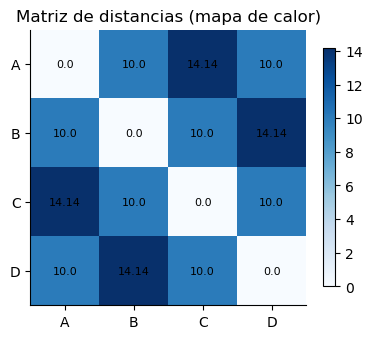

In [7]:
fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(dist_matrix4.values, cmap="Blues")
ax.set_xticks(range(len(cities4))); ax.set_xticklabels(cities4)
ax.set_yticks(range(len(cities4))); ax.set_yticklabels(cities4)
for i in range(len(cities4)):
    for j in range(len(cities4)):
        ax.text(j, i, dist_matrix4.values[i, j], ha="center", va="center", fontsize=8)
ax.set_title("Matriz de distancias (mapa de calor)")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()


## 4. Búsqueda local: el movimiento 2-opt paso a paso

Con solo 4 ciudades, $|S|=3$ y 2-opt encuentra el óptimo en un único
movimiento — no alcanza a mostrar una evolución interesante. Por eso esta
sección usa un ejemplo más rico: **6 ciudades ubicadas en los vértices de
un hexágono regular**, partiendo de un tour inicial deliberadamente
enredado (como podría producir una construcción voraz con mala suerte).

**Conceptos operativos que se implementan a continuación:**

- **Vecindad $N(s)$**: todos los tours alcanzables desde $s$ quitando dos
  arcos e invirtiendo el segmento entre ellos (movimiento 2-opt).
- **Regla de aceptación**: en cada iteración se aplica el mejor
  movimiento encontrado (*best-improvement*).
- **Óptimo local**: el algoritmo se detiene cuando ningún movimiento 2-opt
  reduce el costo del tour.

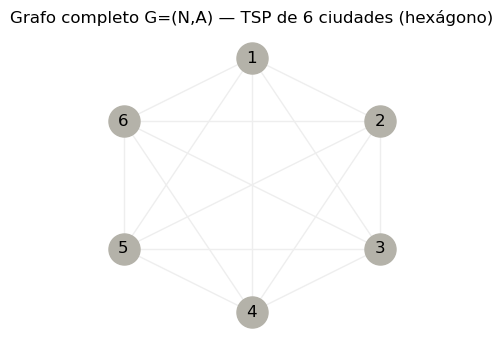

In [8]:
labels6 = ["1", "2", "3", "4", "5", "6"]
coords6 = {}
for i, lab in enumerate(labels6):
    ang = math.pi / 2 - i * (2 * math.pi / 6)  # empezar arriba, sentido horario
    coords6[lab] = (round(4 * math.cos(ang), 3), round(4 * math.sin(ang), 3))

G6 = nx.Graph()
G6.add_nodes_from(labels6)
for c1, c2 in itertools.combinations(labels6, 2):
    G6.add_edge(c1, c2, weight=round(dist(c1, c2, coords6), 2))

fig, ax = plt.subplots(figsize=(4, 4))
nx.draw(G6, pos=coords6, with_labels=True, node_color="#B4B2A9", node_size=500, ax=ax, edge_color="#EEEEEE")
ax.set_title("Grafo completo G=(N,A) — TSP de 6 ciudades (hexágono)")
plt.show()


In [9]:
def tour_length6(order):
    return sum(dist(order[i], order[(i + 1) % len(order)], coords6) for i in range(len(order)))

def two_opt_best_move(order):
    """Busca, entre TODOS los pares de arcos, el intercambio 2-opt que más reduce el costo.
    Devuelve None si el tour ya es un óptimo local."""
    n = len(order)
    best = None
    best_len = tour_length6(order)
    for i in range(n - 1):
        for j in range(i + 2, n):
            if i == 0 and j == n - 1:
                continue
            new_order = order[: i + 1] + order[i + 1 : j + 1][::-1] + order[j + 1 :]
            new_len = tour_length6(new_order)
            if new_len < best_len - 1e-9:
                best_len = new_len
                best = (new_order, order[i], order[i + 1], order[j], order[(j + 1) % n])
    return best

initial6 = ["1", "4", "2", "6", "3", "5"]
current = initial6[:]
history_rows = [{
    "paso": 0, "arco_removido_1": None, "arco_removido_2": None,
    "tour": " → ".join(current + [current[0]]),
    "costo": round(tour_length6(current), 2), "mejora": 0.0,
}]
tours_sequence = [current[:]]

step = 1
while True:
    result = two_opt_best_move(current)
    if result is None:
        break
    new_order, a, b, c, d = result
    prev_cost = tour_length6(current)
    new_cost = tour_length6(new_order)
    history_rows.append({
        "paso": step,
        "arco_removido_1": f"({a},{b})",
        "arco_removido_2": f"({c},{d})",
        "tour": " → ".join(new_order + [new_order[0]]),
        "costo": round(new_cost, 2),
        "mejora": round(prev_cost - new_cost, 2),
    })
    current = new_order
    tours_sequence.append(current[:])
    step += 1

df_2opt = pd.DataFrame(history_rows)
df_2opt


,paso,arco_removido_1,arco_removido_2,tour,costo,mejora
0,0,None,None,1 → 4 → 2 → 6 → 3 → 5 → 1,43.71,0.00
1,1,"(1,4)","(6,3)",1 → 6 → 2 → 4 → 3 → 5 → 1,35.71,8.00
2,2,"(6,2)","(5,1)",1 → 6 → 5 → 3 → 4 → 2 → 1,29.86,5.86
3,3,"(5,3)","(4,2)",1 → 6 → 5 → 4 → 3 → 2 → 1,24.00,5.86


La tabla anterior documenta, paso a paso: qué arcos se eliminaron, el
tour resultante, su costo y la mejora obtenida en esa iteración. El
proceso se detiene solo cuando ningún par de arcos produce una mejora —
es decir, al llegar a un óptimo local.

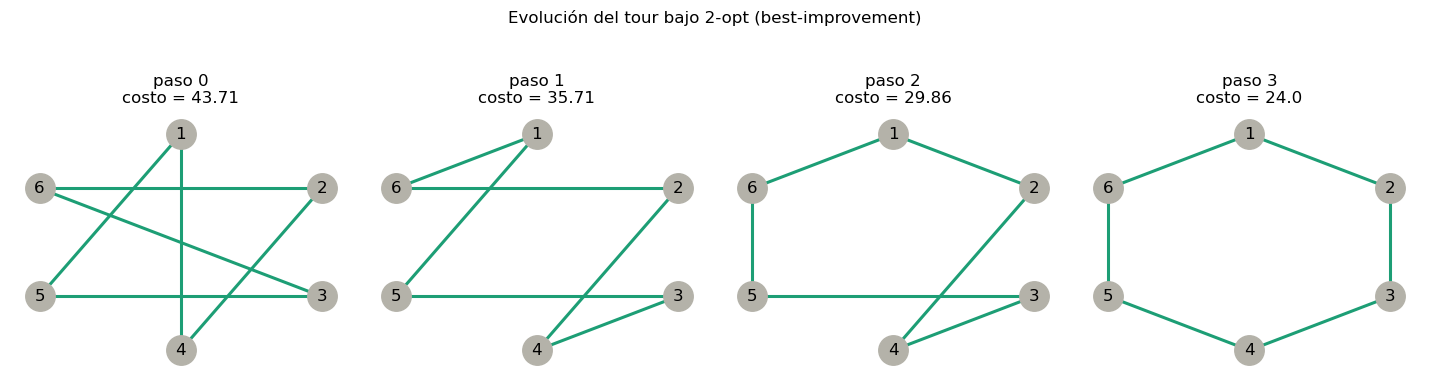

In [10]:
n_steps = len(tours_sequence) - 1
fig, axes = plt.subplots(1, n_steps + 1, figsize=(3.6 * (n_steps + 1), 3.6))
for ax, order, row in zip(axes, tours_sequence, df_2opt.itertuples()):
    path_edges = [(order[i], order[(i + 1) % len(order)]) for i in range(len(order))]
    nx.draw(G6, pos=coords6, with_labels=True, node_color="#B4B2A9", node_size=450,
            ax=ax, edge_color="none")
    nx.draw_networkx_edges(G6, pos=coords6, edgelist=path_edges, edge_color="#1D9E75", width=2.2, ax=ax)
    ax.set_title(f"paso {row.paso}\ncosto = {row.costo}")
fig.suptitle("Evolución del tour bajo 2-opt (best-improvement)", y=1.05)
fig.tight_layout()
plt.show()


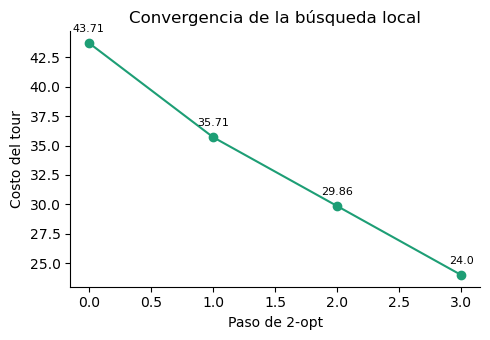

In [11]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(df_2opt["paso"], df_2opt["costo"], marker="o", color="#1D9E75")
for _, r in df_2opt.iterrows():
    ax.annotate(f"{r['costo']}", (r["paso"], r["costo"]), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)
ax.set_xlabel("Paso de 2-opt")
ax.set_ylabel("Costo del tour")
ax.set_title("Convergencia de la búsqueda local")
fig.tight_layout()
plt.show()


En este ejemplo el óptimo local encontrado por 2-opt coincide con el
óptimo global (el perímetro del hexágono). Esto **no está garantizado en
general**: en instancias más grandes, la búsqueda local puede quedar
atrapada en un óptimo local distinto del óptimo global. Este es
precisamente uno de los problemas que las metaheurísticas (como ACO)
están diseñadas para mitigar, explorando el espacio de soluciones de
forma más amplia y estocástica en vez de con una única trayectoria
determinista.

## 5. Conclusiones

- El **método exacto** (enumeración completa) garantiza el óptimo global,
  pero su costo crece factorialmente ($(n-1)!/2$ tours distintos); ya es
  impráctico para instancias de tamaño moderado.
- La **búsqueda local (2-opt)** encuentra buenas soluciones evaluando
  solo un vecindario local en cada paso, con un costo computacional muy
  inferior — pero sin garantía de optimalidad global.
- Ambos métodos comparten la misma base formal $(S, f, \Omega)$
  desarrollada en la sección 1: lo que cambia es *cómo* se recorre $S$
  (exhaustivamente vs. localmente).
- Este contraste —costo computacional vs. calidad de la solución— es
  exactamente el problema que las metaheurísticas, y en particular ACO,
  buscan balancear: usar información heurística y memoria distribuida
  (feromona) para guiar la exploración sin enumerar todo $S$.

## 6. Referencias para profundizar

- Dorigo, M. & Stützle, T. (2004). *Ant Colony Optimization*. MIT Press.
  Capítulos 2 y 3.
- Croes, G. A. (1958). *A method for solving traveling-salesman problems*.
  Operations Research, 6(6) — artículo original que propone el
  movimiento 2-opt.
- Documentación oficial de NetworkX sobre aproximaciones al TSP:
  <https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.approximation.traveling_salesman.traveling_salesman_problem.html>
- Lopez Yse, D. *Solving the Travelling Salesperson Problem (TSP) in
  Python* (Medium) — implementación de fuerza bruta con NetworkX, pandas
  y matplotlib, en un enfoque muy cercano al usado en este notebook:
  <https://lopezyse.medium.com/graphs-solving-the-travelling-salesperson-problem-tsp-in-python-54ec2b315977>
- Gazda, M. *TSP algorithms: 2-opt, 3-opt in python* — comparativa e
  implementación de 2-opt y 3-opt:
  <http://matejgazda.com/tsp-algorithms-2-opt-3-opt-in-python/>
- Documento de estudio complementario de este mismo proyecto:
  `optimizacion-combinatoria-2opt.md`.